In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit
import scipy.constants as spc

In [3]:
res_dressed = "/2024-07-12/2024-07-12T163116_b9652334-cw_sparameter"
punchout =  "/2024-07-12/2024-07-12T163402_1c9bb492-cw_punchout"  # R.T.: -30dB, vna output: -20 ~ 20dB

In [4]:
header = "D:/K_sunada/result/CDY162/"
dd_d = datadict_from_hdf5(header + res_dressed +"/data")


dpr

In [4]:
def resonator(freq, fc, ke, ki, a0, a1, Poff, ed):
    numer = 1j*(freq-fc)+(ke-ki)/2
    denom = 1j*(freq-fc)-(ke+ki)/2
    return (numer/denom * (a0+a1*(freq-freq[0])) * np.exp(1j*(-Poff-ed*2*np.pi*freq))).conj()

In [5]:
def S11_dpr_model(freq, fr, ff, kf_e, kf_i, gamma, g, a0, a1, Poff,ed):
    numer = (1j*(freq-ff)+(kf_e-kf_i)/2)*(1j*(freq-fr)-gamma/2) + (g**2)
    denom = (1j*(freq-ff)-(kf_e+kf_i)/2)*(1j*(freq-fr)-gamma/2) + (g**2)
    model = (numer/denom * (a0+a1*(freq-freq[0])) * np.exp(1j*(Poff-ed*2*np.pi*(freq-freq[0])))).conj()
    return model

In [6]:
freq_d = dd_d['frequency']['values']
s11_d = dd_d['s21']['values']
# freq_b = dd_b['frequency']['values']
# s11_b = dd_b['s21']['values']

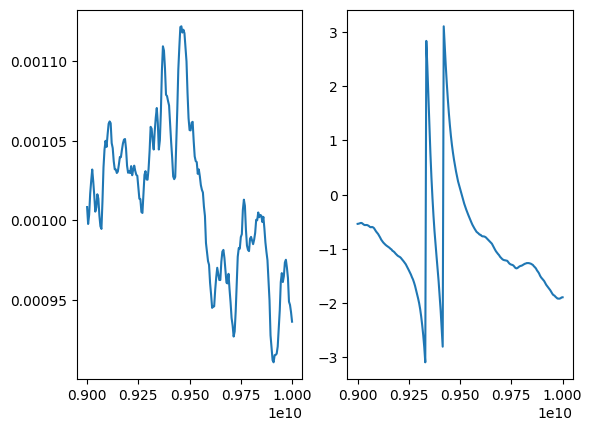

In [7]:
fig,ax = plt.subplots(1,2)
ax[0].plot(freq_d,np.abs(s11_d))
ax[1].plot(freq_d,np.angle(s11_d))

In [8]:
par_ini = {'fr': 9.4e9,  'ff': 9.3e9,    'kf_e': 340e6,   'kf_i': 0.e6,  'g': 14e6, 'gamma': 0.e6,
           'a0': -0.0026,  'a1': 6.5055e-13	,        'Poff': -19575,   'ed': 6e-12}
par_min = {'fr': 0,     'ff': 0,        'kf_e': 0,        'kf_i': 0,        'g': 0,     'gamma': 0,
           'a0': -np.inf,     'a1': -np.inf,  'Poff': -np.inf,'ed': -np.inf}
par_max = {'fr': np.inf,'ff': np.inf,   'kf_e': np.inf,   'kf_i': np.inf,   'g': np.inf,'gamma': np.inf,
           'a0': np.inf,'a1': np.inf,   'Poff': np.inf, 'ed': np.inf}
par_var = {'fr': True, 'ff': True,    'kf_e': True,    'kf_i': False,    'g': True, 'gamma': False,
           'a0': True, 'a1': True,    'Poff': True,  'ed': True}

model=lmfit.Model(S11_dpr_model)
params = model.make_params()

for name in list(par_ini):
    params[name].set(value=par_ini[name])
for name in list(par_min):
    params[name].set(min=par_min[name])  
for name in list(par_max):
    params[name].set(max=par_max[name]) 
for name in list(par_var):
    params[name].set(vary=par_var[name])
    
result_d = model.fit(freq=freq_d, data=s11_d, params=params, method='leastsq')
# result_b = model.fit(freq=freq_b, data=s11_b, params=params, method='leastsq')

In [9]:
par_ini = {
    'fc':8.94e9, 
    'ke':10e6, 
    'ki':1e6, 
    'a0':0.0068, 
    'a1':-2.4e-12, 
    'Poff':8.44, 
    'ed':0
}

par_min = {
    'fc':0, 
    'ke':0, 
    'ki':0, 
    'a0':-np.inf, 
    'a1':-np.inf, 
    'Poff':-np.inf, 
    'ed':-np.inf
}

par_max = {
    'fc':np.inf, 
    'ke':np.inf, 
    'ki':np.inf, 
    'a0':np.inf, 
    'a1':np.inf, 
    'Poff':np.inf, 
    'ed':np.inf
}

par_var = {
    'fc':True, 
    'ke':True, 
    'ki':True, 
    'a0':True, 
    'a1':True, 
    'Poff':True, 
    'ed':False
}
model=lmfit.Model(resonator)
params = model.make_params()

for name in list(par_ini):
    params[name].set(value=par_ini[name])
for name in list(par_min):
    params[name].set(min=par_min[name])  
for name in list(par_max):
    params[name].set(max=par_max[name]) 
for name in list(par_var):
    params[name].set(vary=par_var[name])
    
result_d = model.fit(freq=freq_d, data=s11_d, params=params, method='leastsq')

dressed

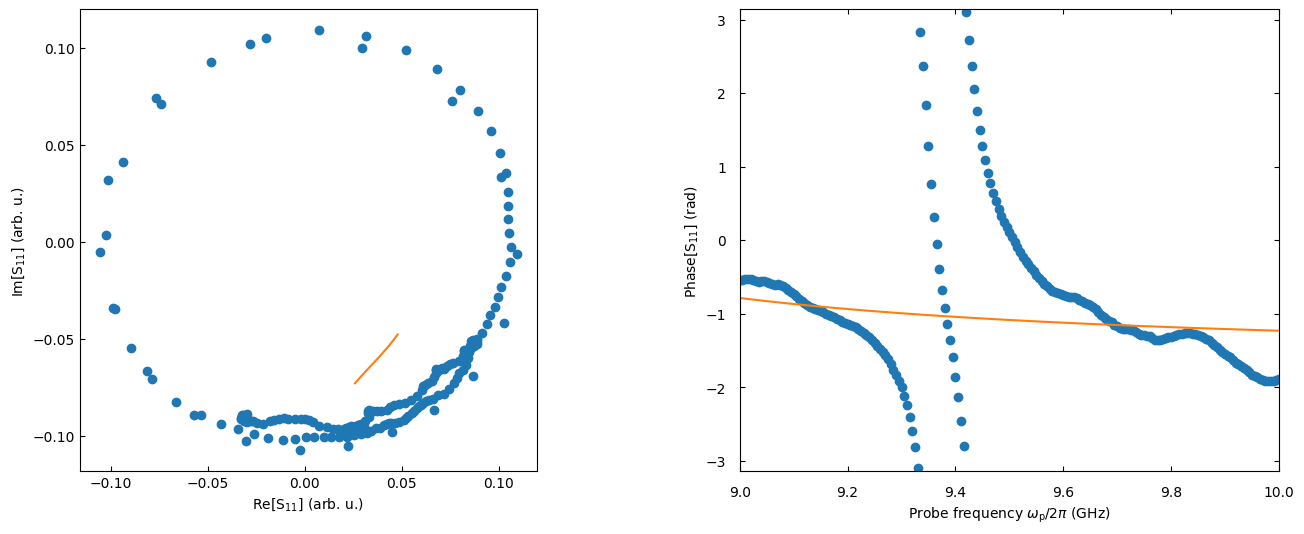

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(16,6))#,constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.subplots_adjust(wspace=0.3)
plt.tick_params(pad = 10, top='on',bottom='on',left='on',right='on',)
ax[0].set_aspect("equal", adjustable="box")
ax[0].set_xlabel('Re[S$_{11}$] (arb. u.) ')
ax[0].set_ylabel('Im[S$_{11}$] (arb. u.) ')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
# plt.xticks([-0.6, -0.4, 0.2, 0, 0.2, 0.4, 0.6])
# ax[0].set_ylim(-0.7, 0.7)
# ax[0].set_xlim(-0.7, 0.7)


ax[1].set_xlabel('Probe frequency $\omega_\mathrm{p}/2\pi$ (GHz)')
ax[1].set_ylabel('Phase[S$_{11}$] (rad) ')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[1].set_xlim(9, 10)
ax[1].set_ylim(-np.pi, np.pi)
# ax[1].set_aspect("equal", adjustable="box")



ax[0].plot(np.real(s11_d)*1e2,np.imag(s11_d)*1e2, ls='', marker='o')
ax[0].plot(np.real(result_d.best_fit)*1e2,np.imag(result_d.best_fit)*1e2)
# ax[0].plot(np.real(result_d.init_fit)*1e2,np.imag(result_d.init_fit)*1e2, color='green', ls='--', )

ax[1].plot(freq_d*1e-9,np.angle(s11_d), ls='', marker='o')
ax[1].plot(freq_d*1e-9,np.angle(result_d.best_fit))
# ax[1].plot(freq_d*1e-9,np.angle(result_d.init_fit), color='green', ls='--', )

result_d
# plt.savefig('dressed_res.png', bbox_inches='tight')
# plt.show()

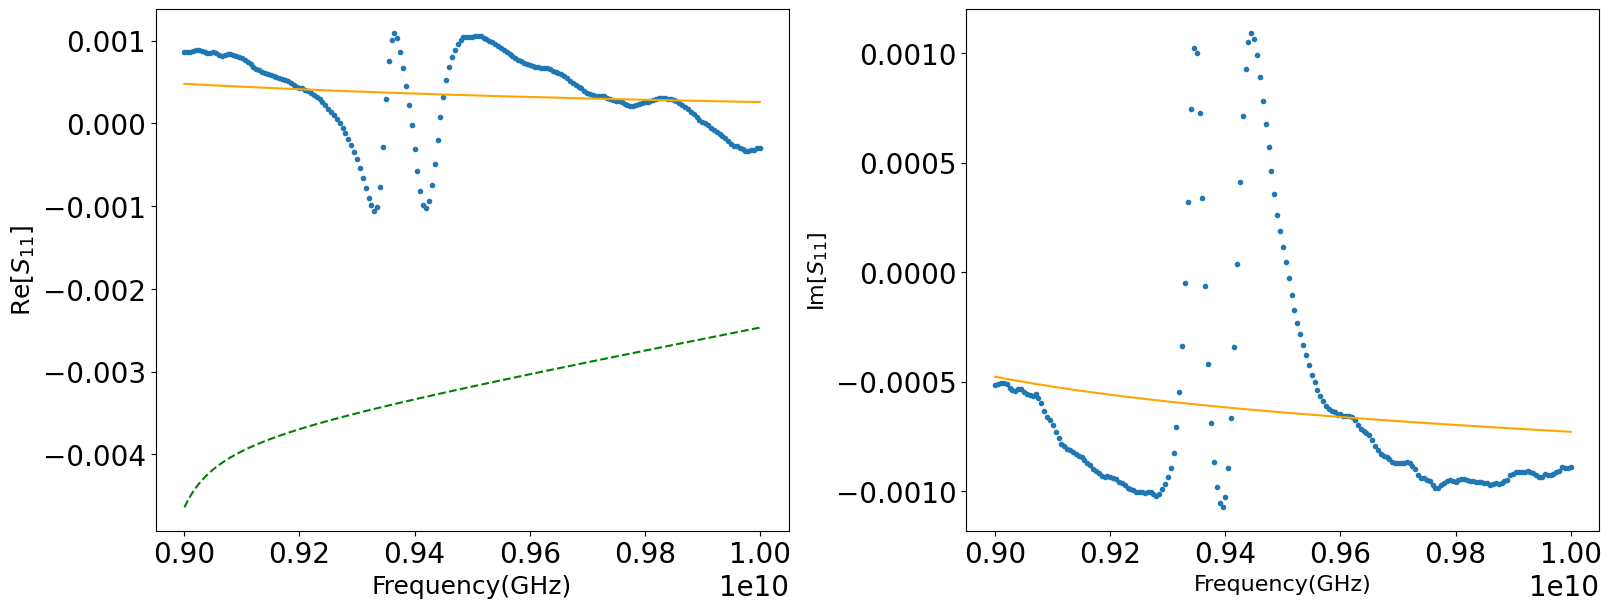

In [11]:
fig, ax = plt.subplots(1,2,figsize=(16,6),constrained_layout=True)
ax[0].set_xlabel('Frequency(GHz)',fontsize=18)
ax[0].set_ylabel('Re[$S_{11}]$', fontsize=18)
ax[1].set_xlabel('Frequency(GHz)',fontsize=16)
ax[1].set_ylabel('Im[$S_{11}]$', fontsize=16)
# ax.tick_params(direction='in')

ax[0].plot(freq_d,np.real(s11_d), ls='', marker='.')
ax[0].plot(freq_d,np.real(result_d.best_fit), color='orange')
ax[0].plot(freq_d,np.real(result_d.init_fit), color='green', ls='--', marker='')
ax[1].plot(freq_d,np.imag(s11_d), ls='', marker='.')
ax[1].plot(freq_d,np.imag(result_d.best_fit), color='orange')


punchout

In [12]:
dd = datadict_from_hdf5(header + punchout +"/data")
dd

s11: (20, 201)
  ⌙ frequency (Hz): (20, 201)
  ⌙ power (dBm): (20,)

In [13]:
dd = datadict_from_hdf5(header + punchout +"/data")
x = np.unique(dd['power']['values'])
y = np.unique(dd['frequency']['values'])
z = dd['s11']['values']

C:\Users\qipe\AppData\Local\Temp\ipykernel_15424\1458322726.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('magma')


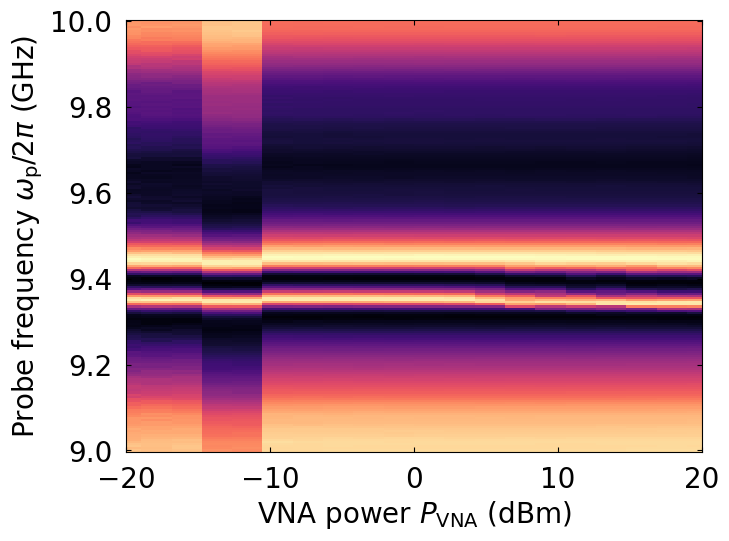

In [14]:
cm = plt.cm.get_cmap('magma')
fig= plt.figure()
plt.rcParams["font.size"] = 20
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

ax = fig.add_axes((0.1, 0.1, 0.9, 0.9))
ax.set_xlabel("VNA power $P_{\mathrm{VNA}}$ (dBm)")
ax.set_ylabel("Probe frequency $\omega_\mathrm{p}/2\pi$ (GHz)")
ax.set_xlim(-20, 20)
# ax.set_ylim(9, 10.)

maingraph = ax.pcolormesh(x,y*1e-9, np.real(z).reshape(20, 201).T, vmin=min(np.unique(np.real(z))), vmax=max(np.unique(np.real(z))), cmap=cm, shading='auto')


plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on')
# plt.savefig('punchout.png', bbox_inches='tight')
plt.show()


平均光子数

In [15]:
def ave_photon_number(Power, k_ex, k_in, omega_r, omega_p):
    n = (k_ex/(((k_in + k_ex)/2)**2 + (omega_r - omega_p)**2))*(Power/(spc.hbar * omega_p))
    return n

In [16]:
spc.hbar

1.0545718176461565e-34

In [17]:
k_ex = 2.0003e8*(2*np.pi)
k_in = 0

omega_r = 1.0267e+10*2*np.pi
omega_p = 1.0177e+10*2*np.pi

Power =  10**((-22.4-10-2.3-50-20)/10) *1e-3#J/s
Power
# ave_photon_number(Power, k_ex, k_in, omega_r, omega_p)


3.3884415613920344e-14

In [18]:
P =  (10**((-50)/10) *1e-3  /6.626e-34 )*1e-9#GHz/s
P


1.509206157561123e+16

In [19]:
kai = (0.13e9)*2*np.pi/2
delta = (10.2503210-8.02-0.00233)*1e9*2*np.pi
g = (kai*delta)**0.5
g

2391075352.76259

In [20]:
delta**2/(4*g**2)

8.569196153846155

In [21]:
k_ex

1256825556.9951327

In [22]:
Power, omega_p, omega_r, k_ex, k_in

(3.3884415613920344e-14,
 63943976871.16665,
 64509463548.81281,
 1256825556.9951327,
 0)

In [23]:
1/(10.209-10.066)

6.993006993007047

# frequency optimization

In [5]:
data = "/2024-07-12/2024-07-12T172854_c664cb34-26_freq_optimize"
dd = datadict_from_hdf5(header + data +"/data")
ed = 0#1e-9/9/(10.25-10)

freq = dd['frequency']['values']
s11_eg = dd['s11_eg']['values']* np.exp(1j*(ed*2*np.pi*freq))
s11_g = dd['s11_g']['values']* np.exp(1j*(ed*2*np.pi*freq))
s11_e = dd['s11_e']['values']* np.exp(1j*(ed*2*np.pi*freq))
s11_eg_div = s11_e / s11_g

eg-peak

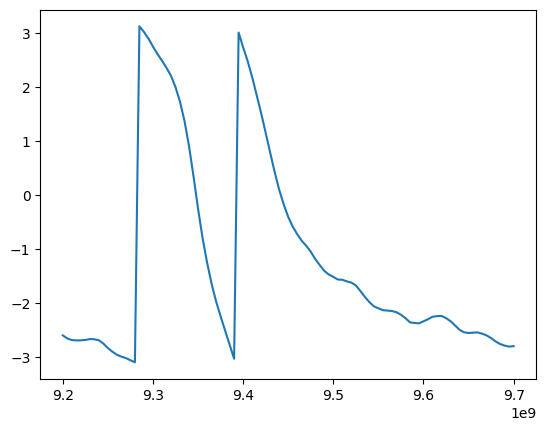

In [8]:
plt.plot(freq, np.angle(s11_g))
plt.show()

In [9]:
def Lorentzian(freq, amp, const, center, k):
    return const + amp*k**2/((freq-center)**2 + k**2)

In [6]:
import sklearn
from sklearn.decomposition import PCA

In [7]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

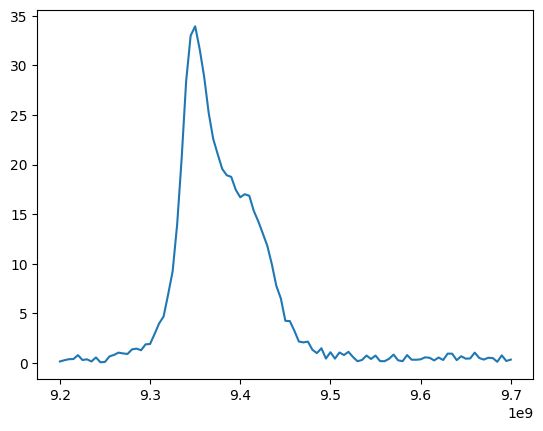

In [8]:
I = s11_eg.real
Q = s11_eg.imag
plt.plot(freq, np.abs(s11_eg))
PCAge = PCA_transform(I, Q)

In [9]:
par_ini = {
    'amp': 40,
    'const':1,
    'center':9.35e9,
    'k':0.008e9
}

par_min = {
    'amp': 0,
    'const':0,
    'center':0,
    'k':0
}

par_max = {
    'amp': np.inf,
    'const':np.inf,
    'center':np.inf,
    'k':np.inf
}

par_vary = {
    'amp': True,
    'const':True,
    'center':True,
    'k':True
}

In [10]:
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

NameError: name 'Lorentzian' is not defined

In [11]:
result = model.fit(data = np.abs(s11_eg), params = params, freq = freq)
result

NameError: name 'model' is not defined

NameError: name 'result' is not defined

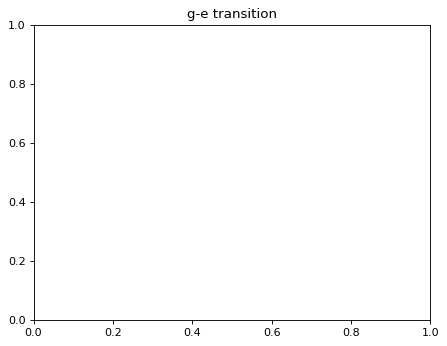

In [12]:
fig, ax = plt.subplots(dpi=80)

plt.title("g-e transition")


plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
plt.xlim(9.2e9, 9.7e9)
plt.ylim(-5, 60)

plt.xlabel("frequency (Hz)")
plt.ylabel("mag[S11](a.u.)")


plt.show()

In [13]:
par_ini = {'fr': 9.3802e9,  'ff': 9.3910e9,    'kf_e': 95.38e6,   'kf_i': 2.e6,  'g': 45e6, 'gamma': 0.e6,
           'a0': 37,  'a1': 6.5055e-13	,        'Poff': -19575,   'ed': 6e-12}
par_min = {'fr': 0,     'ff': 0,        'kf_e': 0,        'kf_i': 0,        'g': 0,     'gamma': 0,
           'a0': -np.inf,     'a1': -np.inf,  'Poff': -np.inf,'ed': -np.inf}
par_max = {'fr': np.inf,'ff': np.inf,   'kf_e': np.inf,   'kf_i': np.inf,   'g': np.inf,'gamma': np.inf,
           'a0': np.inf,'a1': np.inf,   'Poff': np.inf, 'ed': np.inf}
par_var = {'fr': True, 'ff': True,    'kf_e': False,    'kf_i': False,    'g': False, 'gamma': False,
           'a0': True, 'a1': True,    'Poff': True,  'ed': True}

model=lmfit.Model(S11_dpr_model)
params = model.make_params()

for name in list(par_ini):
    params[name].set(value=par_ini[name])
for name in list(par_min):
    params[name].set(min=par_min[name])  
for name in list(par_max):
    params[name].set(max=par_max[name]) 
for name in list(par_var):
    params[name].set(vary=par_var[name])
    
result_g = model.fit(freq=freq, data=s11_g, params=params, method='leastsq')
result_e = model.fit(freq=freq, data=s11_e, params=params, method='leastsq')

NameError: name 'S11_dpr_model' is not defined

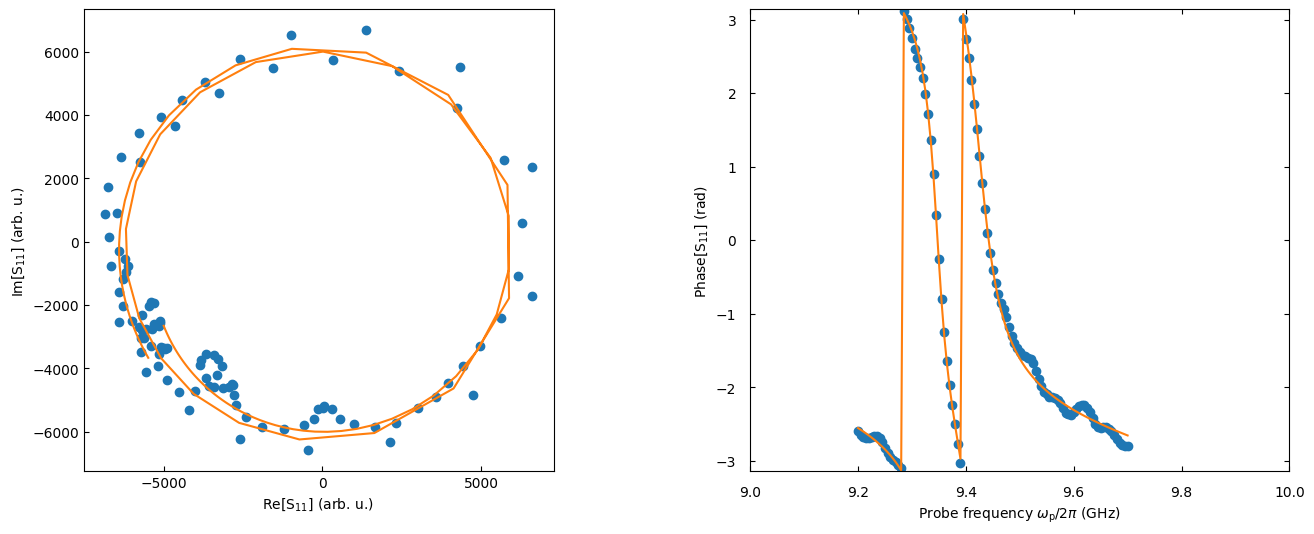

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(16,6))#,constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.subplots_adjust(wspace=0.3)
plt.tick_params(pad = 10, top='on',bottom='on',left='on',right='on',)
ax[0].set_aspect("equal", adjustable="box")
ax[0].set_xlabel('Re[S$_{11}$] (arb. u.) ')
ax[0].set_ylabel('Im[S$_{11}$] (arb. u.) ')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
# plt.xticks([-0.6, -0.4, 0.2, 0, 0.2, 0.4, 0.6])
# ax[0].set_ylim(-0.7, 0.7)
# ax[0].set_xlim(-0.7, 0.7)


ax[1].set_xlabel('Probe frequency $\omega_\mathrm{p}/2\pi$ (GHz)')
ax[1].set_ylabel('Phase[S$_{11}$] (rad) ')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[1].set_xlim(9, 10)
ax[1].set_ylim(-np.pi, np.pi)
# ax[1].set_aspect("equal", adjustable="box")



ax[0].plot(np.real(s11_g)*1e2,np.imag(s11_g)*1e2, ls='', marker='o')
ax[0].plot(np.real(result_g.best_fit)*1e2,np.imag(result_g.best_fit)*1e2)
# ax[0].plot(np.real(result_d.init_fit)*1e2,np.imag(result_d.init_fit)*1e2, color='green', ls='--', )

ax[1].plot(freq*1e-9,np.angle(s11_g), ls='', marker='o')
ax[1].plot(freq*1e-9,np.angle(result_g.best_fit))
# ax[1].plot(freq_d*1e-9,np.angle(result_d.init_fit), color='green', ls='--', )

result_g
# plt.savefig('dressed_res.png', bbox_inches='tight')
# plt.show()

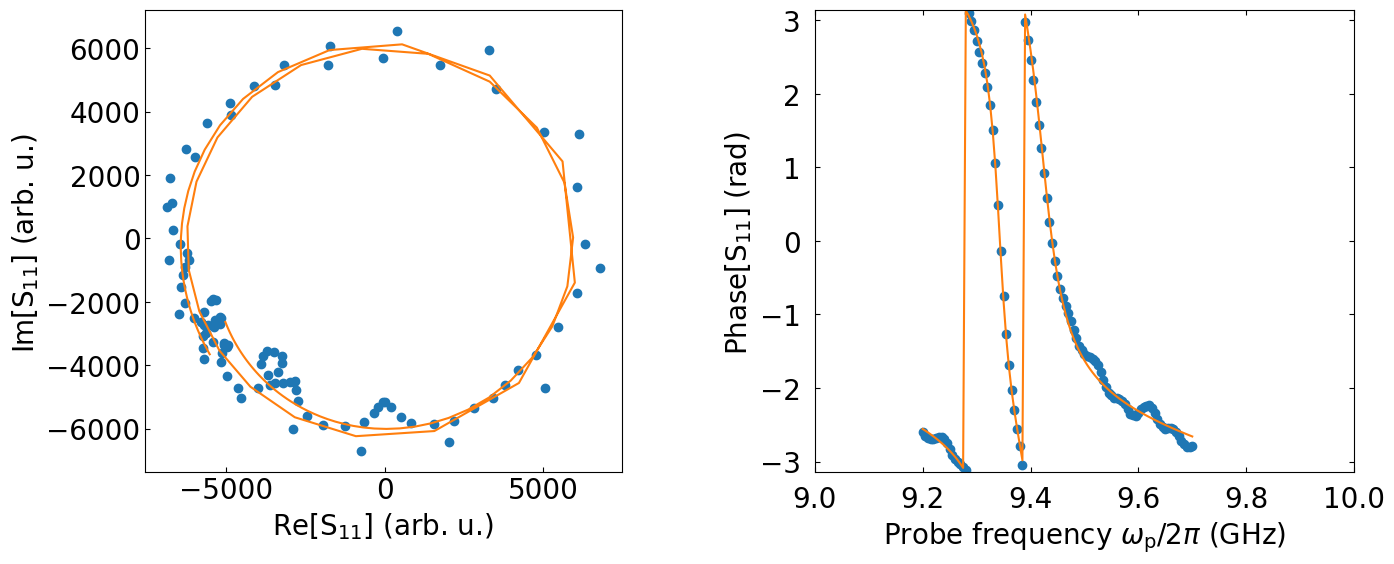

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(16,6))#,constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.subplots_adjust(wspace=0.3)
plt.tick_params(pad = 10, top='on',bottom='on',left='on',right='on',)
ax[0].set_aspect("equal", adjustable="box")
ax[0].set_xlabel('Re[S$_{11}$] (arb. u.) ')
ax[0].set_ylabel('Im[S$_{11}$] (arb. u.) ')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
# plt.xticks([-0.6, -0.4, 0.2, 0, 0.2, 0.4, 0.6])
# ax[0].set_ylim(-0.7, 0.7)
# ax[0].set_xlim(-0.7, 0.7)


ax[1].set_xlabel('Probe frequency $\omega_\mathrm{p}/2\pi$ (GHz)')
ax[1].set_ylabel('Phase[S$_{11}$] (rad) ')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[1].set_xlim(9, 10)
ax[1].set_ylim(-np.pi, np.pi)
# ax[1].set_aspect("equal", adjustable="box")



ax[0].plot(np.real(s11_e)*1e2,np.imag(s11_e)*1e2, ls='', marker='o')
ax[0].plot(np.real(result_e.best_fit)*1e2,np.imag(result_e.best_fit)*1e2)
# ax[0].plot(np.real(result_d.init_fit)*1e2,np.imag(result_d.init_fit)*1e2, color='green', ls='--', )

ax[1].plot(freq*1e-9,np.angle(s11_e), ls='', marker='o')
ax[1].plot(freq*1e-9,np.angle(result_e.best_fit))
# ax[1].plot(freq_d*1e-9,np.angle(result_d.init_fit), color='green', ls='--', )

result_e
# plt.savefig('dressed_res.png', bbox_inches='tight')
# plt.show()

from myamura-san

In [14]:
def s11_ge_dp(f, f_r, f_f, k_ex, k_in, chi, g, gamma, phi):
    k_tot = k_ex + k_in
    s11_g = np.cos(phi) + np.exp(1j*phi) * k_ex * (1j*(f-f_r) - gamma/2)/((1j*(f-f_f)-k_tot/2) * (1j*(f-f_r)-gamma/2) + g**2)
    s11_e = np.cos(phi) + np.exp(1j*phi) * k_ex * (1j*(f-(f_r+chi)) - gamma/2)/((1j*(f-f_f)-k_tot/2) * (1j*(f-(f_r+chi))-gamma/2) + g**2)
    return (s11_e/s11_g).conj()
def guess_params_dp(data,x):
    par_ini = {"f_r":9.3704e9, "f_f":9.3946e9, "k_ex":1.0592e8, "k_in":0.002e9, "chi":-5e6, "g":44499830, "gamma":0, "phi":0,}
    par_max = {"f_r":np.inf, "f_f":np.inf, "k_ex":np.inf, "k_in":np.inf, "chi":0, "g":np.inf, "gamma":np.inf, "phi":np.pi,}
    par_min = {"f_r":0, "f_f":0, "k_ex":0, "k_in":0e-3, "chi":-np.inf, "g":0, "gamma":0, "phi":-np.pi,}
    par_vary = {"f_r":1, "f_f":1, "k_ex":1, "k_in":0, "chi":1, "g":1, "gamma":0, "phi":1}
    return par_ini,par_max,par_min,par_vary
def probe_resonator_fit_dp(data, x):
    import lmfit as lmf
    model = lmf.Model(s11_ge_dp, nan_policy='omit')
    params = model.make_params()
    par_ini,par_max,par_min,par_vary=guess_params_dp(data,x)
    for name in params:
        params[name].set(
            value=par_ini[name],  # ???
            min=par_min[name],  # ???
            max=par_max[name],  # ???
            vary=par_vary[name] # ?????????????
        )
    result=model.fit(data, f=x, params=params, method='leastsq')
    return result

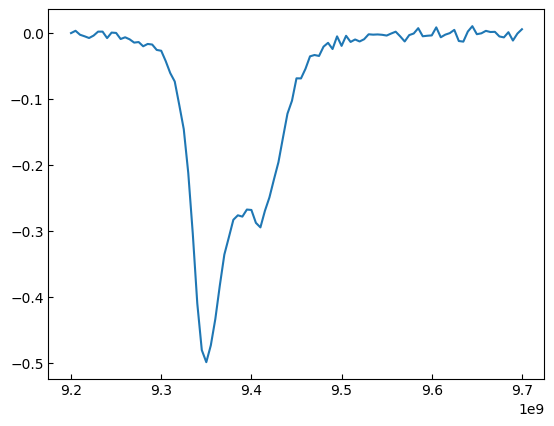

In [15]:
I = s11_eg_div.real
Q = s11_eg_div.imag
plt.plot(freq, np.angle(s11_eg_div))

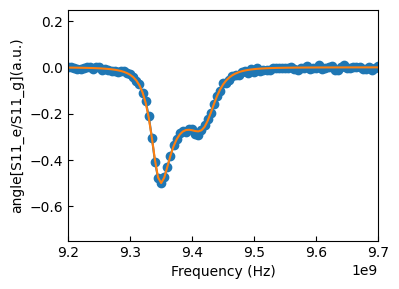

In [17]:
result = probe_resonator_fit_dp(s11_eg_div, freq)

fig, ax = plt.subplots(figsize=(4, 3))


plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
# result.plot_fit(ax = ax)
plt.plot(freq, np.angle(s11_eg_div), marker='o')
plt.plot(freq, np.angle(result.best_fit))
# plt.plot(freq, np.angle(result.init_fit))
plt.xlim(9.2e9, 9.7e9)
plt.ylim(-0.75, 0.25)

plt.xlabel("Frequency (Hz)")
plt.ylabel("angle[S11_e/S11_g](a.u.)")


plt.show()
result


In [23]:
f_hg = 9.3951e9
f_lg = 9.3780e+09
f_he = 9.3946e9
f_le = 9.3719e+09

chi_l = (f_le - f_lg)/2
chi_h = (f_he - f_hg)/2 
chi = chi_l
chi

-3050000.0

In [24]:
freq_q = 7.699e9
alpha = -0.372e9
freq_l = (f_lg+f_le)/2
freq_h = (f_hg+f_he)/2
delta = freq_q - f_lg
print(freq_l, freq_h)
print(freq_q+alpha)
g = np.sqrt((freq_q - freq_l)*((freq_q+alpha) - freq_l)/alpha*chi)
g

9374950000.0 9394850000.0
7327000000.0


167752365.63581237